# AML - Butterflies

This project aims to develop a 3 differente models of Neural Networks (MLP, CNN and ResNets), with different Loss functions

## Files Setup

In [1]:
from google.colab import drive
from pathlib import Path
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
try:
    path = Path('/content/drive/MyDrive/Universidade/Mestrado/2 Semestre/Aprendizagem Computacional Avançada/AML_Butterfly/aca-butterflies')

    if not path.exists():
        raise FileNotFoundError(f"The specified path does not exist: {path}")

except FileNotFoundError:
    path = Path('/content/drive/MyDrive/AdvancedMachineLearning/aca-butterflies')

if not path.exists():
    raise FileNotFoundError(f"The specified path does not exist: {path}")

print(f"Using path: {path}")

Using path: /content/drive/MyDrive/Universidade/Mestrado/2 Semestre/Aprendizagem Computacional Avançada/AML_Butterfly/aca-butterflies


### Load data to Colab

In this section we load the images data to Colab´s server, so it´s now stored at Google´s memory and the code runs so much faster.

Note: add a code cell bellow with the path to your zip file (tip: add it to the same folder as the project, the .gitignore is ok!)

In [3]:
# Load the dataset on Colab machine
!cp "/content/drive/MyDrive/Universidade/Mestrado/2 Semestre/Aprendizagem Computacional Avançada/AML_Butterfly/aca-butterflies.zip" "/content/butterflies.zip"

In [4]:
!unzip -q /content/butterflies.zip -d /content/dataset_local

replace /content/dataset_local/test/Image_0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [6]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.utils.data as data
import torchvision.transforms as transforms

import warnings
warnings.filterwarnings("ignore")

In [7]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cpu


### Dataset manipulation class

In [8]:
BATCH_SIZE = 32
IMAGE_SIZE = 64

In [10]:
class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a dummy image and label in case of error
            dummy_image = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), color='black')
            dummy_label = torch.tensor(0, dtype=torch.long)
            return dummy_image, dummy_label

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [19]:
# load the data
img_dir = Path("/content/dataset_local/train")
# img_dir = os.path.join(path, 'train')
df = pd.read_csv(os.path.join(path, 'train.csv'))

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# encapsulate data into dataloader form
dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)
print(f"Dataset size: {len(dataset)} samples")
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

Dataset size: 5199 samples


In [14]:
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of samples: 5199
Number of classes: 75


In [17]:
os.listdir(img_dir)[:5]  # List first 5 files in the image directory

['train.csv', 'train', 'test']

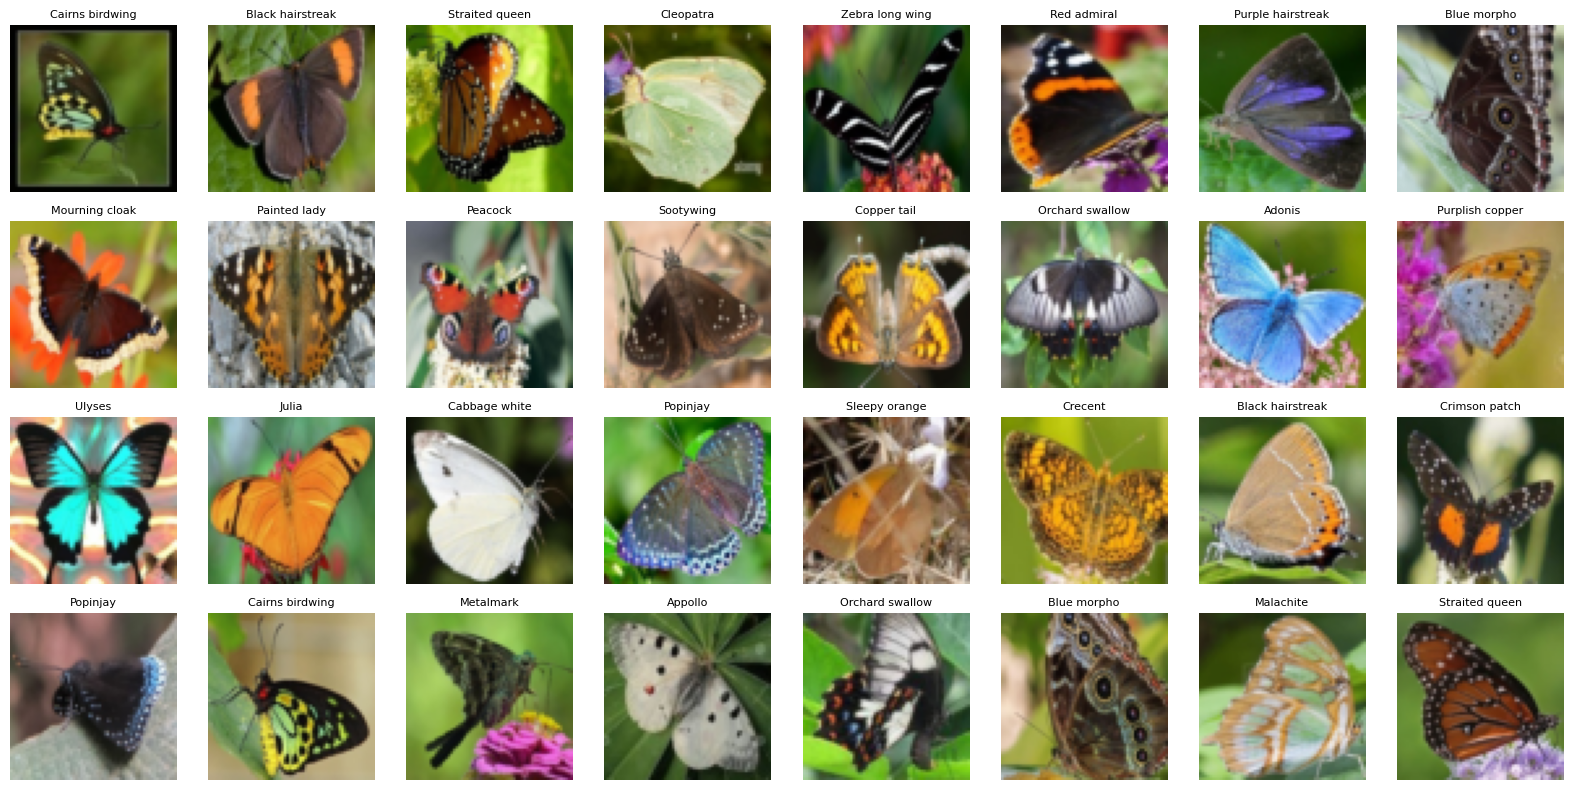

In [20]:
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(len(images)):
    # permutation compute for Matplotlib (C, H, W) -> (H, W, C)
    img = images[i].permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = dataset.classes[label_idx]

    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Dataset analysis

As part of the Data Science pipeline, we first do an Exploratory Data Analysis, let´s see the distribution of the classes in the dataset.

**Inbalanced dataset = model w/ bias**

### Class distribution

Class distribution:
label
MOURNING CLOAK    105
SLEEPY ORANGE      85
ATALA              80
BROWN SIPROETA     79
ORANGE TIP         77
                 ... 
AMERICAN SNOOT     59
CRIMSON PATCH      58
MALACHITE          58
GOLD BANDED        58
WOOD SATYR         57
Name: count, Length: 75, dtype: int64


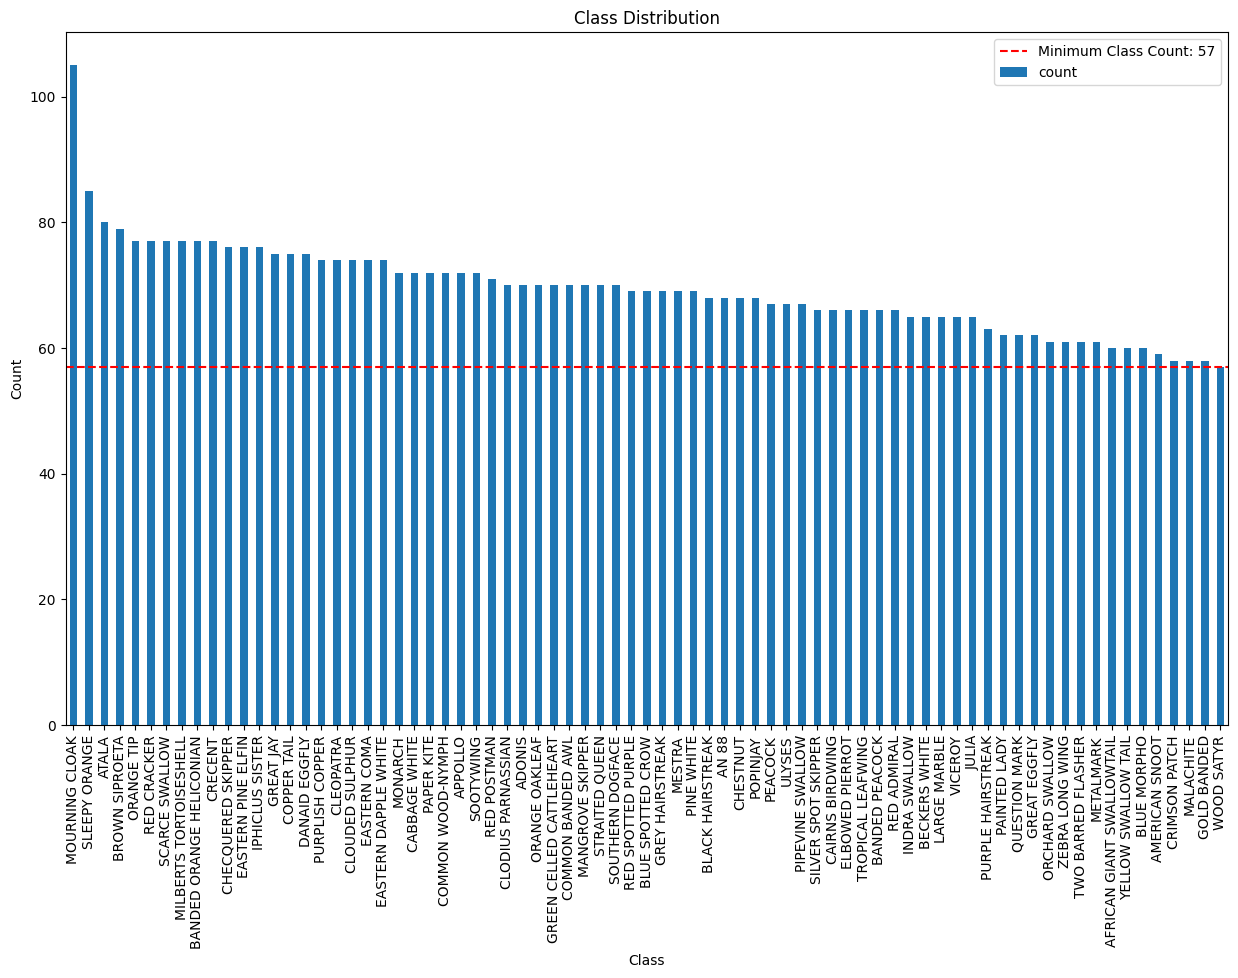

In [ ]:
# Compute class distribution
import matplotlib.pyplot as plt

class_counts = df['label'].value_counts()
print("Class distribution:")
print(class_counts)

# Plot class distribution
plt.figure(figsize=(15, 9))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.axhline(y=class_counts.min(), color='red', linestyle='--', label=f'Minimum Class Count: {class_counts.min()}')
plt.xticks(rotation=90)
plt.legend()
plt.show()

At first analysis the dataset was deeply unbalanced, so we must to explore different techniques to deal with this issue

## Oversampling

**Attention: to perform only 1 time!**

It consists on create new sintetic samples of the minorities classes by transforming the images

In [26]:
import random

random.seed(42)

majority_class = class_counts.idxmax()
minority_classes = class_counts[class_counts < class_counts.max()].index

print(f"Majority class: {majority_class} with {class_counts.max()} samples")
print(f"Minority classes length: {len(minority_classes)}")


for minority_class in minority_classes:
    minority_count = class_counts[minority_class]
    majority_count = class_counts[majority_class]
    samples_to_add = majority_count - minority_count

    print(f"Class '{minority_class}' has {minority_count} samples. Adding {samples_to_add} samples to match the majority class.")

    # Get all images of the minority class
    minority_images = df[df['label'] == minority_class]['filename'].tolist()

    # Randomly sample images from the minority class to create new samples
    for _ in range(samples_to_add):
        img_name = random.choice(minority_images)
        img_path = os.path.join(img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        # Apply random transformations
        transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor()
        ])

        transformed_image = transform(image)

        # Save the transformed image with a new name
        new_img_name = f"{minority_class}_aug_{_}.jpg"
        new_img_path = os.path.join(img_dir, new_img_name)
        transformed_image_pil = transforms.ToPILImage()(transformed_image)
        transformed_image_pil.save(new_img_path)

        # Add the new sample to the dataframe
        new_row = pd.DataFrame([{'filename': new_img_name, 'label': minority_class}])
        df = pd.concat([df, new_row], ignore_index=True)

# Verify the new class distribution
new_class_counts = df['label'].value_counts()
print("New class distribution after oversampling:")
print(new_class_counts)

Majority class: MOURNING CLOAK with 105 samples
Minority classes length: 74
Class 'SLEEPY ORANGE' has 85 samples. Adding 20 samples to match the majority class.
Class 'ATALA' has 80 samples. Adding 25 samples to match the majority class.
Class 'BROWN SIPROETA' has 79 samples. Adding 26 samples to match the majority class.
Class 'ORANGE TIP' has 77 samples. Adding 28 samples to match the majority class.
Class 'RED CRACKER' has 77 samples. Adding 28 samples to match the majority class.
Class 'SCARCE SWALLOW' has 77 samples. Adding 28 samples to match the majority class.
Class 'MILBERTS TORTOISESHELL' has 77 samples. Adding 28 samples to match the majority class.
Class 'BANDED ORANGE HELICONIAN' has 77 samples. Adding 28 samples to match the majority class.
Class 'CRECENT' has 77 samples. Adding 28 samples to match the majority class.
Class 'CHECQUERED SKIPPER' has 76 samples. Adding 29 samples to match the majority class.
Class 'EASTERN PINE ELFIN' has 76 samples. Adding 29 samples to ma

New shape of the dataset after oversampling: (7875, 2)


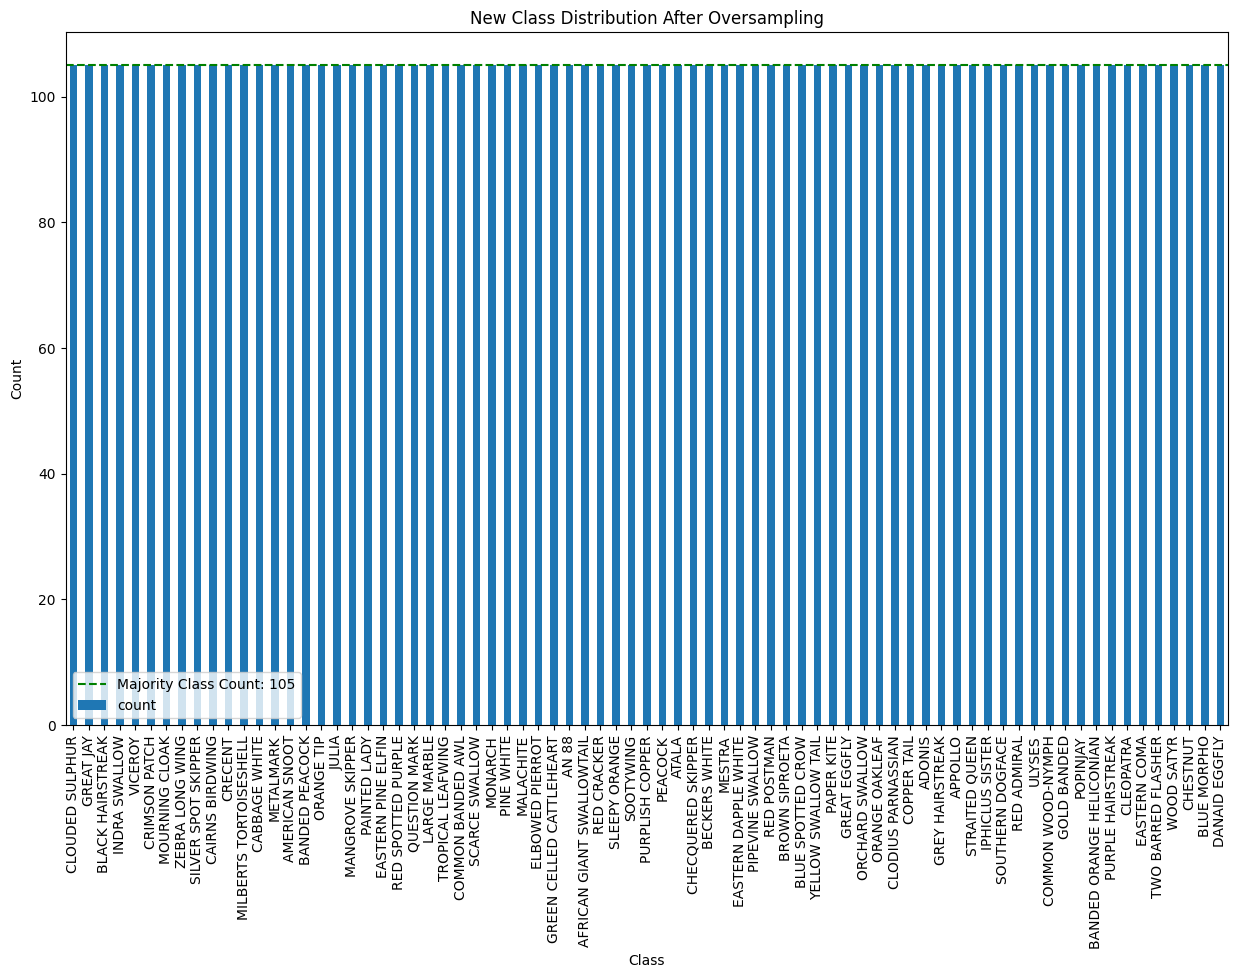

In [27]:
print("New shape of the dataset after oversampling:", df.shape)

plt.figure(figsize=(15, 9))
new_class_counts.plot(kind='bar')
plt.title('New Class Distribution After Oversampling')
plt.xlabel('Class')
plt.ylabel('Count')
plt.axhline(y=class_counts.max(), color='green', linestyle='--', label=f'Majority Class Count: {class_counts.max()}')
plt.xticks(rotation=90)
plt.legend()
plt.show()


In [28]:
df.head()
df.to_csv(os.path.join(path, 'train_oversampled.csv'), index=False)

## Class Weighting

We compute the classes weights on the dataset and save on a Tensor



### Compute the class weights for each class

In [21]:
df_original = pd.read_csv(os.path.join(path, 'train.csv'))

# Compute class distribution for the original dataset
class_counts = df_original['label'].value_counts()
print("Class distribution:")
print(class_counts)

# Compute the weight for each class
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
print("\nClass weights:")
print(class_weights)

# Convert to tensors
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32)
print("\nClass weights tensor:")
print(class_weights_tensor)

loss = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

dataset = ButterflyDataset(df=df_original, img_dir=img_dir, transform=data_transform)
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

Class distribution:
label
MOURNING CLOAK    105
SLEEPY ORANGE      85
ATALA              80
BROWN SIPROETA     79
ORANGE TIP         77
                 ... 
AMERICAN SNOOT     59
CRIMSON PATCH      58
MALACHITE          58
GOLD BANDED        58
WOOD SATYR         57
Name: count, Length: 75, dtype: int64

Class weights:
label
MOURNING CLOAK    0.653473
SLEEPY ORANGE     0.807232
ATALA             0.857684
BROWN SIPROETA    0.868540
ORANGE TIP        0.891100
                    ...   
AMERICAN SNOOT    1.162961
CRIMSON PATCH     1.183012
MALACHITE         1.183012
GOLD BANDED       1.183012
WOOD SATYR        1.203767
Name: count, Length: 75, dtype: float64

Class weights tensor:
tensor([0.6535, 0.8072, 0.8577, 0.8685, 0.8911, 0.8911, 0.8911, 0.8911, 0.8911,
        0.8911, 0.9028, 0.9028, 0.9028, 0.9149, 0.9149, 0.9149, 0.9272, 0.9272,
        0.9272, 0.9272, 0.9272, 0.9530, 0.9530, 0.9530, 0.9530, 0.9530, 0.9530,
        0.9664, 0.9802, 0.9802, 0.9802, 0.9802, 0.9802, 0.9802, 0.9802, 

### WeightedRandomSampler

In [22]:
from torch.utils.data import WeightedRandomSampler

df_original = pd.read_csv(os.path.join(path, 'train.csv'))

# 1. Contiamo quante immagini ci sono per ogni specie
class_counts = df_original['label'].value_counts()
print("Class counts:", class_counts)

# 2. Calcoliamo i pesi (più la classe è rara, più alto è il peso)
weights = (1.0 / class_counts).to_dict()
print("Class weights:", weights)


# 3. Mappiamo ogni riga del DataFrame al suo peso corrispondente
# Questo trasforma i nomi in numeri (pesi) automaticamente
sample_weights = df_original['label'].map(weights).tolist()

# 3. Creiamo il sampler
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# 4. Creiamo il DataLoader (fondamentale: shuffle deve essere False se usi il sampler)
train_loader = data.DataLoader(dataset, batch_size=32, sampler=sampler)

print("Sampler configurato e pronto!")

print("✅ Sampler creato con successo!")
print(f"Esempio primi 3 pesi nella lista: {sample_weights[:3]}")

Class counts: label
MOURNING CLOAK    105
SLEEPY ORANGE      85
ATALA              80
BROWN SIPROETA     79
ORANGE TIP         77
                 ... 
AMERICAN SNOOT     59
CRIMSON PATCH      58
MALACHITE          58
GOLD BANDED        58
WOOD SATYR         57
Name: count, Length: 75, dtype: int64
Class weights: {'MOURNING CLOAK': 0.009523809523809525, 'SLEEPY ORANGE': 0.011764705882352941, 'ATALA': 0.0125, 'BROWN SIPROETA': 0.012658227848101266, 'ORANGE TIP': 0.012987012987012988, 'RED CRACKER': 0.012987012987012988, 'SCARCE SWALLOW': 0.012987012987012988, 'MILBERTS TORTOISESHELL': 0.012987012987012988, 'BANDED ORANGE HELICONIAN': 0.012987012987012988, 'CRECENT': 0.012987012987012988, 'CHECQUERED SKIPPER': 0.013157894736842105, 'EASTERN PINE ELFIN': 0.013157894736842105, 'IPHICLUS SISTER': 0.013157894736842105, 'GREAT JAY': 0.013333333333333334, 'COPPER TAIL': 0.013333333333333334, 'DANAID EGGFLY': 0.013333333333333334, 'PURPLISH COPPER': 0.013513513513513514, 'CLEOPATRA': 0.01351351

In [23]:
# Verify the sampler by checking the distribution of classes in a few batches
images, labels = next(iter(train_loader))

# 2. count the lables in the batch
unique, counts = torch.unique(labels, return_counts=True)

print("--- CHECK BATCH ---")
print(f"Batch dimension: {labels.size(0)} immagini")
print(f"Different classes in this batch: {len(unique)}")
print("\nBatch distribution (Class: Count):")
for u, c in zip(unique, counts):
    print(f"Specie {u.item()}: present {c.item()} times")

# 3. Verifica visiva
if len(unique) > 10:
    print("\n✅ IL SAMPLER FUNZIONA: Il batch contiene molte classi diverse.")
else:
    print("\n⚠️ ATTENZIONE: Se vedi sempre la stessa classe, c'è un problema.")

--- CHECK BATCH ---
Batch dimension: 32 immagini
Different classes in this batch: 25

Batch distribution (Class: Count):
Specie 1: present 4 times
Specie 5: present 1 times
Specie 10: present 1 times
Specie 15: present 1 times
Specie 17: present 1 times
Specie 19: present 1 times
Specie 21: present 1 times
Specie 22: present 1 times
Specie 25: present 2 times
Specie 27: present 1 times
Specie 28: present 1 times
Specie 31: present 1 times
Specie 35: present 1 times
Specie 37: present 1 times
Specie 38: present 1 times
Specie 39: present 1 times
Specie 43: present 1 times
Specie 44: present 1 times
Specie 45: present 1 times
Specie 46: present 1 times
Specie 49: present 2 times
Specie 52: present 3 times
Specie 53: present 1 times
Specie 68: present 1 times
Specie 72: present 1 times

✅ IL SAMPLER FUNZIONA: Il batch contiene molte classi diverse.


In [24]:
from torch.utils.data import WeightedRandomSampler

def create_weighted_sampler(df, label_col='label'):
    """
    Creates a WeightedRandomSampler to handle class imbalance in the dataset.

    Args:
        df (pd.DataFrame): The DataFrame containing the data (e.g., train_df).
        label_col (str): The name of the column containing the classes (default: 'label').

    Returns:
        WeightedRandomSampler: The configured sampler to be used in the DataLoader.
    """

    # 1. Count how many images there are for each class
    class_counts = df[label_col].value_counts()

    # 2. Calculate the weights (1 / frequency of the class)
    weights = (1.0 / class_counts).to_dict()

    # 3. Map each row of the DataFrame to its corresponding weight
    sample_weights = df[label_col].map(weights).tolist()

    # It's good practice to convert the list of weights to a PyTorch Tensor
    sample_weights_tensor = torch.tensor(sample_weights, dtype=torch.float)

    # 4. Create the sampler
    sampler = WeightedRandomSampler(
        weights=sample_weights_tensor,
        num_samples=len(sample_weights_tensor),
        replacement=True
    )

    return sampler

## Preparation

### Modeling Preparation

In this section we will slip our train dataset in Train, validation and test sets. Because the "test" set that we have doesnt has labels.

Also we define the train function to all NNs

In [29]:
from sklearn.model_selection import train_test_split

# 1.First we split the data into training/validation (85%) and test (15%)
train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df['label']
)

# 2. Then, we split the remaining data between training and validation
# 0.176 aprox represents 15% of the original total (0.15 / 0.85)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.176,
    random_state=42,
    stratify=train_val_df['label']
)

print(f"Training: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

#* Sampler
sampler = create_weighted_sampler(train_df, label_col='label')

#* DataLoaders
# Training
train_dataset = ButterflyDataset(df=train_df, img_dir=img_dir, transform=data_transform)
train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)

# Validation
val_dataset = ButterflyDataset(df=val_df, img_dir=img_dir, transform=data_transform)
val_loader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Test
test_dataset = ButterflyDataset(df=test_df, img_dir=img_dir, transform=data_transform)
test_loader = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


#* =============================== OVERSAMPLED DATASET ===============================
df_oversampled = pd.read_csv(os.path.join(path, 'train_oversampled.csv'))
over_train_val_df, over_test_df = train_test_split(
    df_oversampled,
    test_size=0.15,
    random_state=42,
    stratify=df_oversampled['label']
)
over_train_df, over_val_df = train_test_split(
    over_train_val_df,
    test_size=0.176,
    random_state=42,
    stratify=over_train_val_df['label']
)

print(f"Oversampled Training: {len(over_train_df)} | Oversampled Validation: {len(over_val_df)} | Oversampled Test: {len(over_test_df)}")

# Training - OVERSAMPLED
oversampled_train_dataset = ButterflyDataset(df=over_train_df, img_dir=img_dir, transform=data_transform)
oversampled_train_loader = data.DataLoader(oversampled_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Validation - OVERSAMPLED
oversampled_val_dataset = ButterflyDataset(df=over_val_df, img_dir=img_dir, transform=data_transform)
oversampled_val_loader = data.DataLoader(oversampled_val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Test - OVERSAMPLED
oversampled_test_dataset = ButterflyDataset(df=over_test_df, img_dir=img_dir, transform=data_transform)
oversampled_test_loader = data.DataLoader(oversampled_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

#* ============================== COMPETITION TEST DATASET ==============================
test_img_dir = Path('/content/dataset_local/test')


Training: 5515 | Validation: 1178 | Test: 1182
Oversampled Training: 5515 | Oversampled Validation: 1178 | Oversampled Test: 1182


In [30]:
import copy
import torch

def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=25, patience=5, scheduler=None):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    # Early Stopping variables
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        print(f'[{epoch+1}/{num_epochs}]', end=' ')
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode (enables Dropout, BatchNorm, etc.)
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluation mode (disables Dropout, etc.)
                dataloader = val_loader
                
            running_loss = 0.0
            running_corrects = 0
            total_samples = 0
            
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    # Backward e and optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        
                # Stats
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                total_samples += inputs.size(0)
                
            epoch_loss = running_loss / total_samples
            epoch_acc = running_corrects.double() / total_samples
            
            print(f'{phase.capitalize()}: Loss = {epoch_loss:.4f} Accuracy = {epoch_acc*100:.2f}% |', end=' ')
            
            # Save history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                
                # Update Scheduler if exists (based on Validation Loss)
                if scheduler is not None:
                    scheduler.step(epoch_loss)
                
                # Early Stopping logic
                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
        
        # Early Stopping check after each epoch
        if epochs_no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch+1}! Validation loss did not improve for {patience} epochs.')
            break
            
        print()
        
    print(f'\nBest Validation Loss: {best_val_loss:.4f}')
    
    model.load_state_dict(best_model_wts)
    return history

In [31]:
import matplotlib.pyplot as plt

def plot_results(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title('Loss per Epoch')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.title('Accuracy per Epoch')
    plt.xlabel('Epochs')
    plt.legend()

    plt.show()


### Experimentation Preparation

In [32]:
import itertools
import torch
import torch.nn as nn
import torch.optim as optim
import gc


def set_seed(seed=42):
    """Set a fixed seed for reproducibility"""
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# def run_experiments(model_class, model_args, param_grid, train_loader, val_loader, device, num_epochs=10):
#     results = {}
#     best_val_acc = 0.0
#     best_config = None
#     best_exp_name = ""

#     # Extract parameters for the grid search
#     archs = param_grid.get('architecture', [{}])
#     lrs = param_grid.get('learning_rate', [0.001])
#     opts = param_grid.get('optimizer', ['Adam'])
#     losses = param_grid.get('loss', ['CrossEntropy'])

#     combinations = list(itertools.product(archs, lrs, opts, losses))
#     total_experiments = len(combinations)
#     print(f"Beginning {total_experiments} experiments for {model_class.__name__}...\n")

#     for arch_params, lr, opt_name, loss_name in combinations:
#         # Formating the experiment name for better logging
#         arch_str = "-".join([f"{k}:{v}" for k, v in arch_params.items()]) if arch_params else "Default"
#         exp_name = f"Arch:[{arch_str}] | LR:{lr} | Opt:{opt_name} | Loss:{loss_name}"

#         print(f"{'='*80}\n({combinations.index((arch_params, lr, opt_name, loss_name)) + 1}/{total_experiments})Training -> {exp_name}\n{'='*80}")

#         set_seed(42)

#         # Unpacking dynamic architecture parameters
#         model = model_class(**model_args, **arch_params).to(device)

#         if loss_name == 'CrossEntropy':
#             criterion = nn.CrossEntropyLoss()
#         elif loss_name == 'MultiMargin':
#             criterion = nn.MultiMarginLoss()
#         else:
#             raise ValueError(f"Loss {loss_name} not supported.")

#         if opt_name == 'Adam':
#             optimizer = optim.Adam(model.parameters(), lr=lr)
#         elif opt_name == 'RMSprop':
#             optimizer = optim.RMSprop(model.parameters(), lr=lr)
#         else:
#             raise ValueError(f"Optimizer {opt_name} not supported.")

#         # Training
#         history = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs)

#         # Save Results
#         results[exp_name] = history

#         # Check if it's the best
#         max_acc_neste_treino = max(history['val_acc'])
#         if max_acc_neste_treino > best_val_acc:
#             best_val_acc = max_acc_neste_treino
#             best_exp_name = exp_name
#             best_config = {
#                 'architecture': arch_params,
#                 'learning_rate': lr,
#                 'optimizer': opt_name,
#                 'loss': loss_name
#             }

#         # --- Memory Management ---
#         del model
#         del criterion
#         del optimizer
#         gc.collect() # Forces Python to free up memory from unused variables
#         if device.type == 'cuda' or device.type == 'mps':
#             torch.cuda.empty_cache() # Clears GPU memory for the next loop

#     print("\n" + "="*25)
#     print(f"BEST CONFIG FOR {model_class.__name__}:")
#     print(f"Name: {best_exp_name}")
#     print(f"Maximum Validation Accuracy: {best_val_acc:.2f}%")
#     print(f"Parameters: {best_config}")
#     print("="*25 + "\n")

#     return results, best_config

import itertools
import torch
import torch.optim as optim
import torch.nn as nn

def run_experiments(model_name, grid, train_loader, val_loader, device, num_classes=75, num_epochs=30, patience=5):
    """
    Function to run a grid search over different hyperparameters for a given model.
    
    model_name: string, name of the model to instantiate (e.g., 'MLP', 'CNN', 'ResNet')
    grid: dictionary with lists of hyperparameters to test (e.g., {'architecture': [...], 'learning_rate': [...], 'optimizer': [...], 'loss': [...], 'weight_decay': [...]})
    train_loader: DataLoader for training data
    val_loader: DataLoader for validation data
    device: torch device (e.g., 'cuda', 'mps', 'cpu')
    num_classes: int, number of output classes for the model
    num_epochs: int, maximum number of epochs to train each model
    patience: int, number of epochs with no improvement after which training will be stopped (early stopping)
    """
    best_overall_acc = 0.0
    best_config = None
    results = []
    
    keys = grid.keys()
    combinations = list(itertools.product(*grid.values()))
    
    print(f"Iniciando Grid Search para o modelo: {model_name}")
    print(f"Total de combinações a testar: {len(combinations)}\n")
    
    for idx, combo in enumerate(combinations):
        config = dict(zip(keys, combo))
        print(f"=== Experimento {idx+1}/{len(combinations)} ===")
        print(f"Configuração: {config}")
        
        # ---------------------------------------------------------
        # 1. Initialize the Model based on the current configuration
        # ---------------------------------------------------------
        if model_name == 'MLP':
            model = ButterflyMLP(**config['architecture']).to(device)
            
        elif model_name == 'CNN':
            model = ButterflyCNN(**config['architecture']).to(device)
            
        elif model_name == 'ResNet':
            model = ButterflyResNet(**config['architecture'], num_classes=num_classes).to(device)
            
        else:
            raise ValueError(f"Modelo {model_name} não suportado!")

        # ---------------------------------------------------------
        # 2. Definition of the Loss Function
        # ---------------------------------------------------------
        if config['loss'] == 'CrossEntropy':
            criterion = nn.CrossEntropyLoss()
        elif config['loss'] == 'MultiMargin':
            criterion = nn.MultiMarginLoss()
        else:
            criterion = nn.CrossEntropyLoss() # Default fallback
            
        # ---------------------------------------------------------
        # 3. Definition of the Optimizer
        # ---------------------------------------------------------
        wd = config.get('weight_decay', 0.0) # Weight decay: It´s for L2 regularization, helps to prevent overfitting by penalizing large weights.
        lr = config.get('learning_rate', 0.001) 
        
        if config['optimizer'] == 'Adam':
            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        elif config['optimizer'] == 'SGD':
            optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
        elif config['optimizer'] == 'RMSprop':
            optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=wd)
        else:
            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
            
        # ---------------------------------------------------------
        # 4. Initialize the Learning Rate Scheduler (optional)
        # ---------------------------------------------------------
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
        
        history = train_model(
            model=model, 
            train_loader=train_loader, 
            val_loader=val_loader, 
            criterion=criterion, 
            optimizer=optimizer, 
            device=device, 
            num_epochs=num_epochs,          # Max epochs for training
            patience=patience,              # Early stopping patience (number of epochs with no improvement after which training will be stopped)
            scheduler=scheduler
        )
        
        # ---------------------------------------------------------
        # 5. Evaluate and Save Results
        # ---------------------------------------------------------
        best_val_acc_of_run = max(history['val_acc'])
        print(f"Best validation accuracy of this experiment: {best_val_acc_of_run*100:.2f}%\n")
        
        results.append({
            'config': config,
            'history': history,
            'best_val_acc': best_val_acc_of_run,
            # Save the model weights of the best epoch for this configuration
            'model_weights': copy.deepcopy(model.state_dict()) 
        })
        
        if best_val_acc_of_run > best_overall_acc:
            best_overall_acc = best_val_acc_of_run
            best_config = config
            
    print(f"End of experiments for {model_name}!")
    print(f"Best Validation Accuracy: {best_overall_acc*100:.2f}%")
    print(f"Best Configuration:\n{best_config} \n")
    
    return results, best_config

### Test Preparation

In [33]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_on_test(model, test_loader, device, class_names=None):
    """
    Evaluates the final model on the Test Set and prints the classification report and confusion matrix.
    Args:
        model: the trained model to evaluate
        test_loader: DataLoader for the test set
        device: 'cuda' or 'cpu'
        class_names: list of class names corresponding to the labels (optional, for better report readability)
    """
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    print("Evaluating the final model on the Test Set...")
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            # Save predictions and labels for the report and confusion matrix
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\n" + "="*15)
    print("FINAL RESULTS (TEST SET)")
    print("="*15 + "\n")


    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    # Generate and Plot the Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(20, 16))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)

    plt.title('Confusion Matrix', fontsize=16)
    plt.ylabel('True Class', fontsize=12)
    plt.xlabel('Predicted Class', fontsize=12)


    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return all_labels, all_preds

### Competition Preparation

In [40]:
import pandas as pd
import torch
from PIL import Image
import os

def generate_kaggle_submission(model, test_dir, transform, device, class_names, save_name='submission.csv'):
    """
    Args:
        model: Modelo treinado.
        test_dir: Caminho da pasta de teste.
        transform: Transformações de validação/teste.
        device: 'cuda' ou 'cpu'.
        class_names: Lista com os nomes das classes (ex: train_dataset.classes).
        save_name: Nome do arquivo CSV.
    """
    model.eval()
    results = []
    
    # Lista e ordena os arquivos para garantir a ordem
    test_files = sorted([f for f in os.listdir(test_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
    
    print(f"A processar {len(test_files)} imagens para a submissão...")
    
    with torch.no_grad():
        for filename in test_files:
            # 1. Carregar e preparar a imagem
            img_path = os.path.join(test_dir, filename)
            image = Image.open(img_path).convert('RGB')
            input_tensor = transform(image).unsqueeze(0).to(device)
            
            # 2. Predição
            outputs = model(input_tensor)
            _, predicted_idx = torch.max(outputs, 1)
            
            # 3. Converter índice para o NOME da classe
            # predicted_idx.item() dá o número, class_names[...] dá o nome
            label_extenso = class_names[predicted_idx.item()]
            
            results.append({
                "filename": filename,
                "label": label_extenso
            })
            
    # 4. Criar o CSV
    df = pd.DataFrame(results)
    save_dir = os.path.dirname(path)
    df.to_csv(os.path.join(save_dir, save_name), index=False)
    print(f"Sucesso! Submissão guardada em: {os.path.join(save_dir, save_name)}")
    return df

## Multilayer Perceptron

### Implementation

In [23]:
# Implement the MLP
import torch.nn as nn
import torch.nn.functional as F

class ButterflyMLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        """MLP class for butterfly classification.
        Args:
            input_size: number of input features (e.g., 3*64*64 for 64x64 RGB images)
            hidden_size: list of integers specifying the number of neurons in each hidden layer
            num_classes: number of output classes (butterfly species)"""

        super(ButterflyMLP, self).__init__()

        self.name = "Multilayer Perceptron"
        self.flatten = nn.Flatten()
        self.layers = nn.ModuleList()
        self.activations = nn.ModuleList()

        # Without hidden layers, just a single linear layer
        if len(hidden_size) == 0:
            self.layers.append(nn.Linear(input_size, num_classes))
        else:

            # First layer in the network
            self.layers.append(nn.Linear(input_size, hidden_size[0]))
            self.activations.append(nn.ReLU())

            for i in range(len(hidden_size) - 1):
                self.layers.append(nn.Linear(hidden_size[i], hidden_size[i+1]))
                self.activations.append(nn.ReLU())

            # Output layer
            self.layers.append(nn.Linear(hidden_size[-1], num_classes))

    def forward(self, x):
        # x ha forma [batch, 3, 64, 64]
        x = self.flatten(x) # diventa [batch, 12288]

        for i in range(len(self.activations)):
            x = self.layers[i](x)
            x = self.activations[i](x)

        # Passiamo l'ultimo layer (quello di output) SENZA attivazione
        x = self.layers[-1](x)

        return x

**About the MLP parameters:**

Bottleneck Architecture

- **Input Layer (input_size):** Since MLPs cannot process 2D spatial structures (width and height) like CNNs do, we need to "flatten" the image into a single 1D vector. The size is calculated as 3 * IMAGE_SIZE * IMAGE_SIZE, where 3 represents the RGB color channels. For a 64x64 image, our network receives an input vector of 12,288 values.

- **Hidden Layers (hidden_size = [512, 256]):** We opted for a bottleneck (funnel) architecture with two hidden layers.

    - <u>The first layer (512 neurons)</u> takes in the 12,000+ pixels and starts extracting basic patterns.

    - <u>The second layer (256 neurons)</u> compresses this information further, forcing the network to focus only on the most important and abstract features of the butterflies. This acts as a regularization technique to help prevent overfitting (memorization).

- **Output Layer (num_classes):** The final layer has exactly the same number of neurons as the number of butterfly species in our dataset. Each neuron outputs a "score" (logit) indicating the probability that the given image belongs to that specific species.

### Weighted Samples

#### Experimentation

In [14]:
# import torch.optim as optim

# #* MLP parameters
input_size = 3 * IMAGE_SIZE * IMAGE_SIZE
hidden_size = [512, 256]
num_classes = len(dataset.classes)

# mlp_args = {
#     'input_size': input_size,
#     'num_classes': num_classes
# }

# #* Tests grid for Hyperparameters
# tests_grid = {
#     'architecture': [
#         {'hidden_size': [512, 256]},
#         {'hidden_size': [1024, 512, 128]}
#     ],
#     'learning_rate': [0.001, 0.0001],
#     'optimizer': ['Adam', 'RMSprop'],
#     'loss': ['CrossEntropy', 'MultiMargin']
# }

# #* Run the experiments
# mlp_all_results, mlp_best_config = run_experiments(
#     model_class=ButterflyMLP,     # Models class name
#     model_args=mlp_args,          # Fixed arguments for the model (like input_size and num_classes)
#     param_grid=tests_grid,        # The grid for tests
#     train_loader=train_loader,    # Training DataLoader (with the sampler)
#     val_loader=val_loader,        # Validation DataLoader
#     device=device,                # 'cuda' or 'cpu'
#     num_epochs=10                  # Number of epochs per configuration
# )

grid_mlp = {
    'architecture': [
        {"input_size": input_size, 'hidden_size': [512, 256], "num_classes": num_classes},
        {"input_size": input_size, 'hidden_size': [1024, 512, 256], "num_classes": num_classes}
    ],
    'learning_rate': [0.001, 0.0001],
    'weight_decay': [1e-4],
    'optimizer': ['Adam', 'SGD', 'RMSprop'],
    'loss': ['CrossEntropy', 'MultiMargin']
}

results_mlp, best_config_mlp = run_experiments(model_name='MLP', 
                                               grid=grid_mlp, 
                                               train_loader=train_loader, 
                                               val_loader=val_loader, 
                                               device=device,
                                               num_classes=num_classes,
                                               num_epochs=30,
                                               patience=6)

NameError: name 'run_experiments' is not defined

#### Test

Training the final MLP with the best configuration: {'architecture': {'input_size': 12288, 'hidden_size': [512, 256], 'num_classes': 75}, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'optimizer': 'Adam', 'loss': 'CrossEntropy'}
(1/25) Train: Loss = 4.1838 Accuracy = 3.19% | Val: Loss = 3.9221 Accuracy = 5.27% | 
(2/25) Train: Loss = 3.6582 Accuracy = 8.29% | Val: Loss = 3.5964 Accuracy = 8.87% | 
(3/25) Train: Loss = 3.3213 Accuracy = 14.69% | Val: Loss = 3.2950 Accuracy = 13.24% | 
(4/25) Train: Loss = 3.0636 Accuracy = 19.97% | Val: Loss = 3.2418 Accuracy = 15.42% | 
(5/25) Train: Loss = 2.8645 Accuracy = 24.80% | Val: Loss = 3.0478 Accuracy = 20.95% | 
(6/25) Train: Loss = 2.6917 Accuracy = 27.46% | Val: Loss = 3.0777 Accuracy = 19.28% | 
(7/25) Train: Loss = 2.5767 Accuracy = 30.49% | Val: Loss = 2.9514 Accuracy = 22.37% | 
(8/25) Train: Loss = 2.4275 Accuracy = 33.92% | Val: Loss = 2.9327 Accuracy = 24.29% | 
(9/25) Train: Loss = 2.3013 Accuracy = 37.57% | Val: Loss = 2.9339 Ac

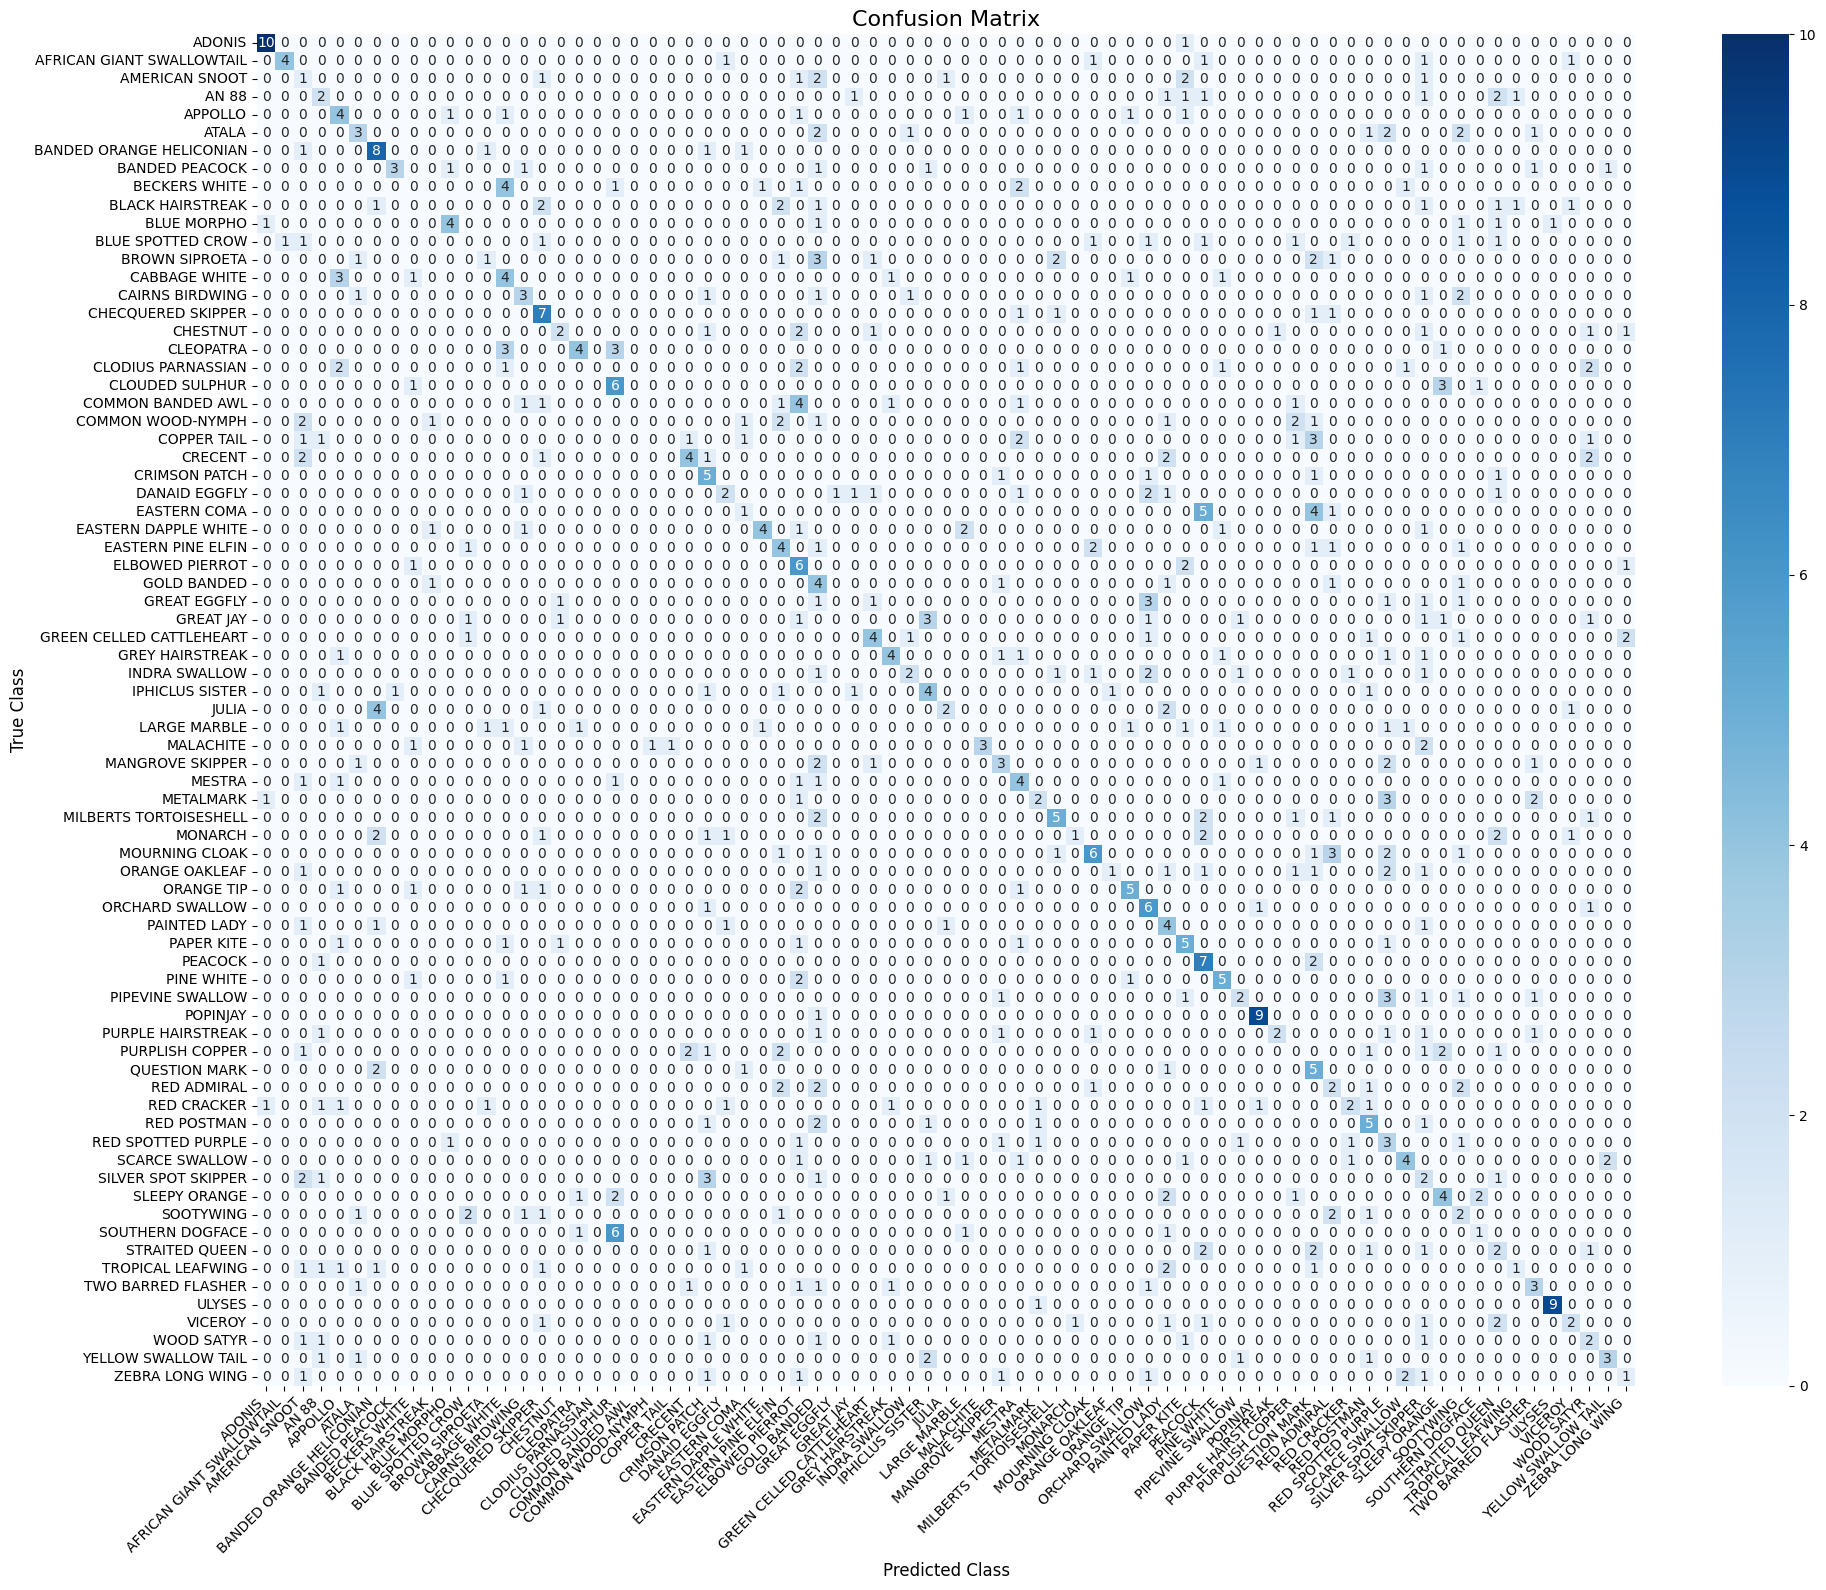

In [ ]:
final_mlp_model = ButterflyMLP(**best_config_mlp['architecture']).to(device)

if best_config_mlp['loss'] == 'CrossEntropy':
    criterion_final = nn.CrossEntropyLoss()
else:
    criterion_final = nn.MultiMarginLoss()

if best_config_mlp['optimizer'] == 'Adam':
    optimizer_final = optim.Adam(final_mlp_model.parameters(), lr=best_config_mlp['learning_rate'], weight_decay=best_config_mlp.get('weight_decay', 0.0))
else:
    optimizer_final = optim.RMSprop(final_mlp_model.parameters(), lr=best_config_mlp['learning_rate'], weight_decay=best_config_mlp.get('weight_decay', 0.0))

scheduler_final = optim.lr_scheduler.ReduceLROnPlateau(optimizer_final, mode='min', factor=0.5, patience=3)

print(f"Training the final MLP with the best configuration: {best_config_mlp}")
history_final = train_model(model=final_mlp_model, 
                            train_loader=train_loader, 
                            val_loader=val_loader, 
                            criterion=criterion_final, 
                            optimizer=optimizer_final, 
                            device=device, 
                            num_epochs=25,
                            patience=5,
                            scheduler=scheduler_final
                            )

checkpoint_mlp = {
    'model_name': 'ButterflyMLP',
    'best_config': best_config_mlp,
    'model_weights': final_mlp_model.state_dict(),
    'class_names': test_dataset.classes
}

dir_save = os.path.dirname(path) # Main Project Directory
save_path = os.path.join(dir_save, 'models/best_mlp_model.pth')

torch.save(checkpoint_mlp, save_path)
print(f"Model saved successfully to: {save_path}")

# Evaluate the final model on the Test Set
labels_reais, labels_previstos = evaluate_on_test(
    final_mlp_model,
    test_loader,
    device,
    class_names=test_dataset.classes
)

In [ ]:
plot_results(history_final)

## Convolutiona Neural Network (CNN)

### Implementation

In [36]:
import torch.nn as nn
import torch.nn.functional as F

class ButterflyCNN(nn.Module):
    def __init__(self, num_classes, base_filters=32, fc_neurons=256, dropout_rate=0.5):
        """
        Convolutional Neural Network for 64x64 images.
        Args:
            num_classes: Number of butterfly species.
            base_filters: Initial number of filters (doubles at each layer).
            fc_neurons: Number of neurons in the final dense layer.
            dropout_rate: Dropout rate to prevent overfitting.
        """
        super(ButterflyCNN, self).__init__()
        self.name = "Convolutional Neural Network"
        
        # ==========================================
        # FEATURE EXTRACTION (Convolutional Layers) 
        # ==========================================
        # Input: 3 channels (RGB)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=base_filters, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=base_filters, out_channels=base_filters*2, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=base_filters*2, out_channels=base_filters*4, kernel_size=3, padding=1)
        
        # Pooling layer (MaxPool) after each convolution to reduce spatial dimensions 
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # ==========================================
        # CLASSIFICATION (Dense Layers)
        # ==========================================
        # Initial: 64x64 -> passes through pool1 -> 32x32 -> pool2 -> 16x16 -> pool3 -> 8x8
        # The total number of values to flatten is: (Filters from the last conv) * 8 * 8
        flatten_size = (base_filters * 4) * 8 * 8
        
        self.fc1 = nn.Linear(flatten_size, fc_neurons)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(fc_neurons, num_classes)

    def forward(self, x):
        # Pass through Convolution -> Activation (ReLU) -> Reduction (MaxPool)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        # "Flatten" the 3 dimensions (Channels, Height, Width) into a single 1D vector
        x = x.view(x.size(0), -1) 
        
        # Final Dense Layers with Dropout for Regularization
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # Output layer (logits for each class)
        
        return x

### Weighted Samples

#### Experimentation

In [13]:
grid_cnn = {
    'architecture': [
        # Simple architecture
        {'base_filters': 16, 'fc_neurons': 128, 'dropout_rate': 0.3, 'num_classes': len(test_dataset.classes)}, 
        # Deeper architecture with more filters and neurons
        {'base_filters': 32, 'fc_neurons': 256, 'dropout_rate': 0.5, 'num_classes': len(test_dataset.classes)}  
    ],
    'learning_rate': [0.001, 0.0001],
    'weight_decay': [1e-4],
    'optimizer': ['Adam', 'RMSprop', 'SGD'],
    'loss': ['CrossEntropy']
}

cnn_results, cnn_best_config = run_experiments(model_name='CNN', 
                                               grid=grid_cnn, 
                                               train_loader=train_loader, 
                                               val_loader=val_loader, 
                                               device=device,
                                               num_classes=num_classes,
                                               num_epochs=10,
                                               patience=6)
        

NameError: name 'test_dataset' is not defined

#### Test

In [ ]:
final_CNN_model = ButterflyCNN(**cnn_best_config['architecture']).to(device)

if cnn_best_config['loss'] == 'CrossEntropy':
    criterion_final = nn.CrossEntropyLoss()
else:
    criterion_final = nn.MultiMarginLoss()

if cnn_best_config['optimizer'] == 'Adam':
    optimizer_final = optim.Adam(final_CNN_model.parameters(), lr=cnn_best_config['learning_rate'])
else:
    optimizer_final = optim.RMSprop(final_CNN_model.parameters(), lr=cnn_best_config['learning_rate'])

cnn_scheduler_final = optim.lr_scheduler.ReduceLROnPlateau(optimizer_final, mode='min', factor=0.5, patience=3)

print(f"Training the final CNN with the best configuration: {cnn_best_config}")
history_final = train_model(model=final_CNN_model, 
                            train_loader=train_loader, 
                            val_loader=val_loader, 
                            criterion=criterion_final, 
                            optimizer=optimizer_final, 
                            device=device, 
                            num_epochs=30,
                            scheduler=cnn_scheduler_final)

# save the best model configuration for later use
save_path = os.path.join(path, 'models/best_cnn_model.pth')
checkpoint_cnn = {
    'model_name': 'ButterflyCNN',
    'best_config': cnn_best_config,
    'model_weights': final_CNN_model.state_dict(),
    'class_names': test_dataset.classes
}

dir_save = os.path.dirname(path) # Main Project Directory
save_path = os.path.join(dir_save, 'models/best_cnn_model.pth')

torch.save(checkpoint_cnn, save_path)
print(f"Model saved successfully to: {save_path}")

# Evaluate the final model on the Test Set
labels_reais, labels_previstos = evaluate_on_test(
    final_CNN_model,
    test_loader,
    device,
    class_names=test_dataset.classes
)

NameError: name 'cnn_best_config' is not defined

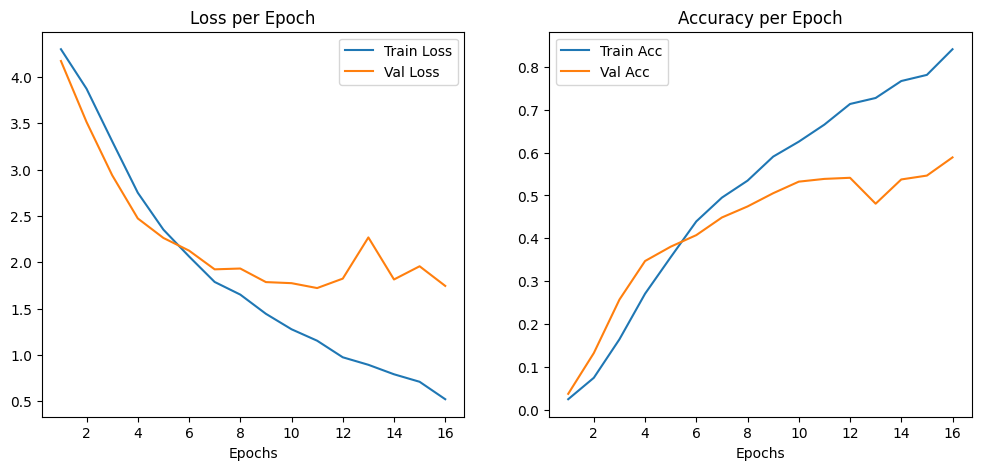

In [ ]:
plot_results(history_final)

### Oversampled

#### Experimentation

In [24]:
num_classes = len(test_dataset.classes)

grid_cnn = {
    'architecture': [
        # Simple architecture
        {'base_filters': 16, 'fc_neurons': 128, 'dropout_rate': 0.3, 'num_classes': len(test_dataset.classes)}, 
        # Deeper architecture with more filters and neurons
        {'base_filters': 32, 'fc_neurons': 256, 'dropout_rate': 0.5, 'num_classes': len(test_dataset.classes)}  
    ],
    'learning_rate': [0.001, 0.0001],
    'weight_decay': [1e-4],
    'optimizer': ['Adam', 'RMSprop', 'SGD'],
    'loss': ['CrossEntropy', 'MultiMargin']
}

oversampled_cnn_results, oversampled_cnn_best_config = run_experiments(model_name='CNN', 
                                               grid=grid_cnn, 
                                               train_loader=oversampled_train_loader, 
                                               val_loader=oversampled_val_loader, 
                                               device=device,
                                               num_classes=num_classes,
                                               num_epochs=10,
                                               patience=6)

Iniciando Grid Search para o modelo: CNN
Total de combinações a testar: 24

=== Experimento 1/24 ===
Configuração: {'architecture': {'base_filters': 16, 'fc_neurons': 128, 'dropout_rate': 0.3, 'num_classes': 75}, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'optimizer': 'Adam', 'loss': 'CrossEntropy'}
[1/10] Train: Loss = 4.1922 Accuracy = 2.19% | Val: Loss = 3.8680 Accuracy = 5.52% | 
[2/10] Train: Loss = 3.7528 Accuracy = 7.04% | Val: Loss = 3.4355 Accuracy = 13.41% | 
[3/10] Train: Loss = 3.3798 Accuracy = 12.02% | Val: Loss = 3.1014 Accuracy = 18.25% | 
[4/10] Train: Loss = 3.1126 Accuracy = 17.12% | Val: Loss = 2.8268 Accuracy = 23.09% | 
[5/10] Train: Loss = 2.9622 Accuracy = 19.93% | Val: Loss = 2.7429 Accuracy = 25.47% | 
[6/10] Train: Loss = 2.8244 Accuracy = 22.28% | Val: Loss = 2.6158 Accuracy = 28.52% | 
[7/10] Train: Loss = 2.6541 Accuracy = 26.58% | Val: Loss = 2.4768 Accuracy = 33.11% | 
[8/10] Train: Loss = 2.5124 Accuracy = 29.59% | Val: Loss = 2.3949 Accuracy = 35.

#### Test

Training the final CNN with the best configuration: {'architecture': {'base_filters': 32, 'fc_neurons': 256, 'dropout_rate': 0.5, 'num_classes': 75}, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'optimizer': 'RMSprop', 'loss': 'CrossEntropy'}
[1/45] Train: Loss = 4.3332 Accuracy = 2.70% | Val: Loss = 3.8474 Accuracy = 6.20% | 
[2/45] Train: Loss = 3.6434 Accuracy = 8.27% | Val: Loss = 3.3245 Accuracy = 13.67% | 
[3/45] Train: Loss = 3.2262 Accuracy = 15.45% | Val: Loss = 2.9361 Accuracy = 22.67% | 
[4/45] Train: Loss = 2.8144 Accuracy = 24.57% | Val: Loss = 2.7259 Accuracy = 29.37% | 
[5/45] Train: Loss = 2.5059 Accuracy = 31.80% | Val: Loss = 2.3962 Accuracy = 36.42% | 
[6/45] Train: Loss = 2.1985 Accuracy = 39.66% | Val: Loss = 2.0742 Accuracy = 43.89% | 
[7/45] Train: Loss = 1.9282 Accuracy = 45.08% | Val: Loss = 2.0183 Accuracy = 43.29% | 
[8/45] Train: Loss = 1.7374 Accuracy = 50.21% | Val: Loss = 1.9084 Accuracy = 47.20% | 
[9/45] Train: Loss = 1.5102 Accuracy = 55.78% | Val: 

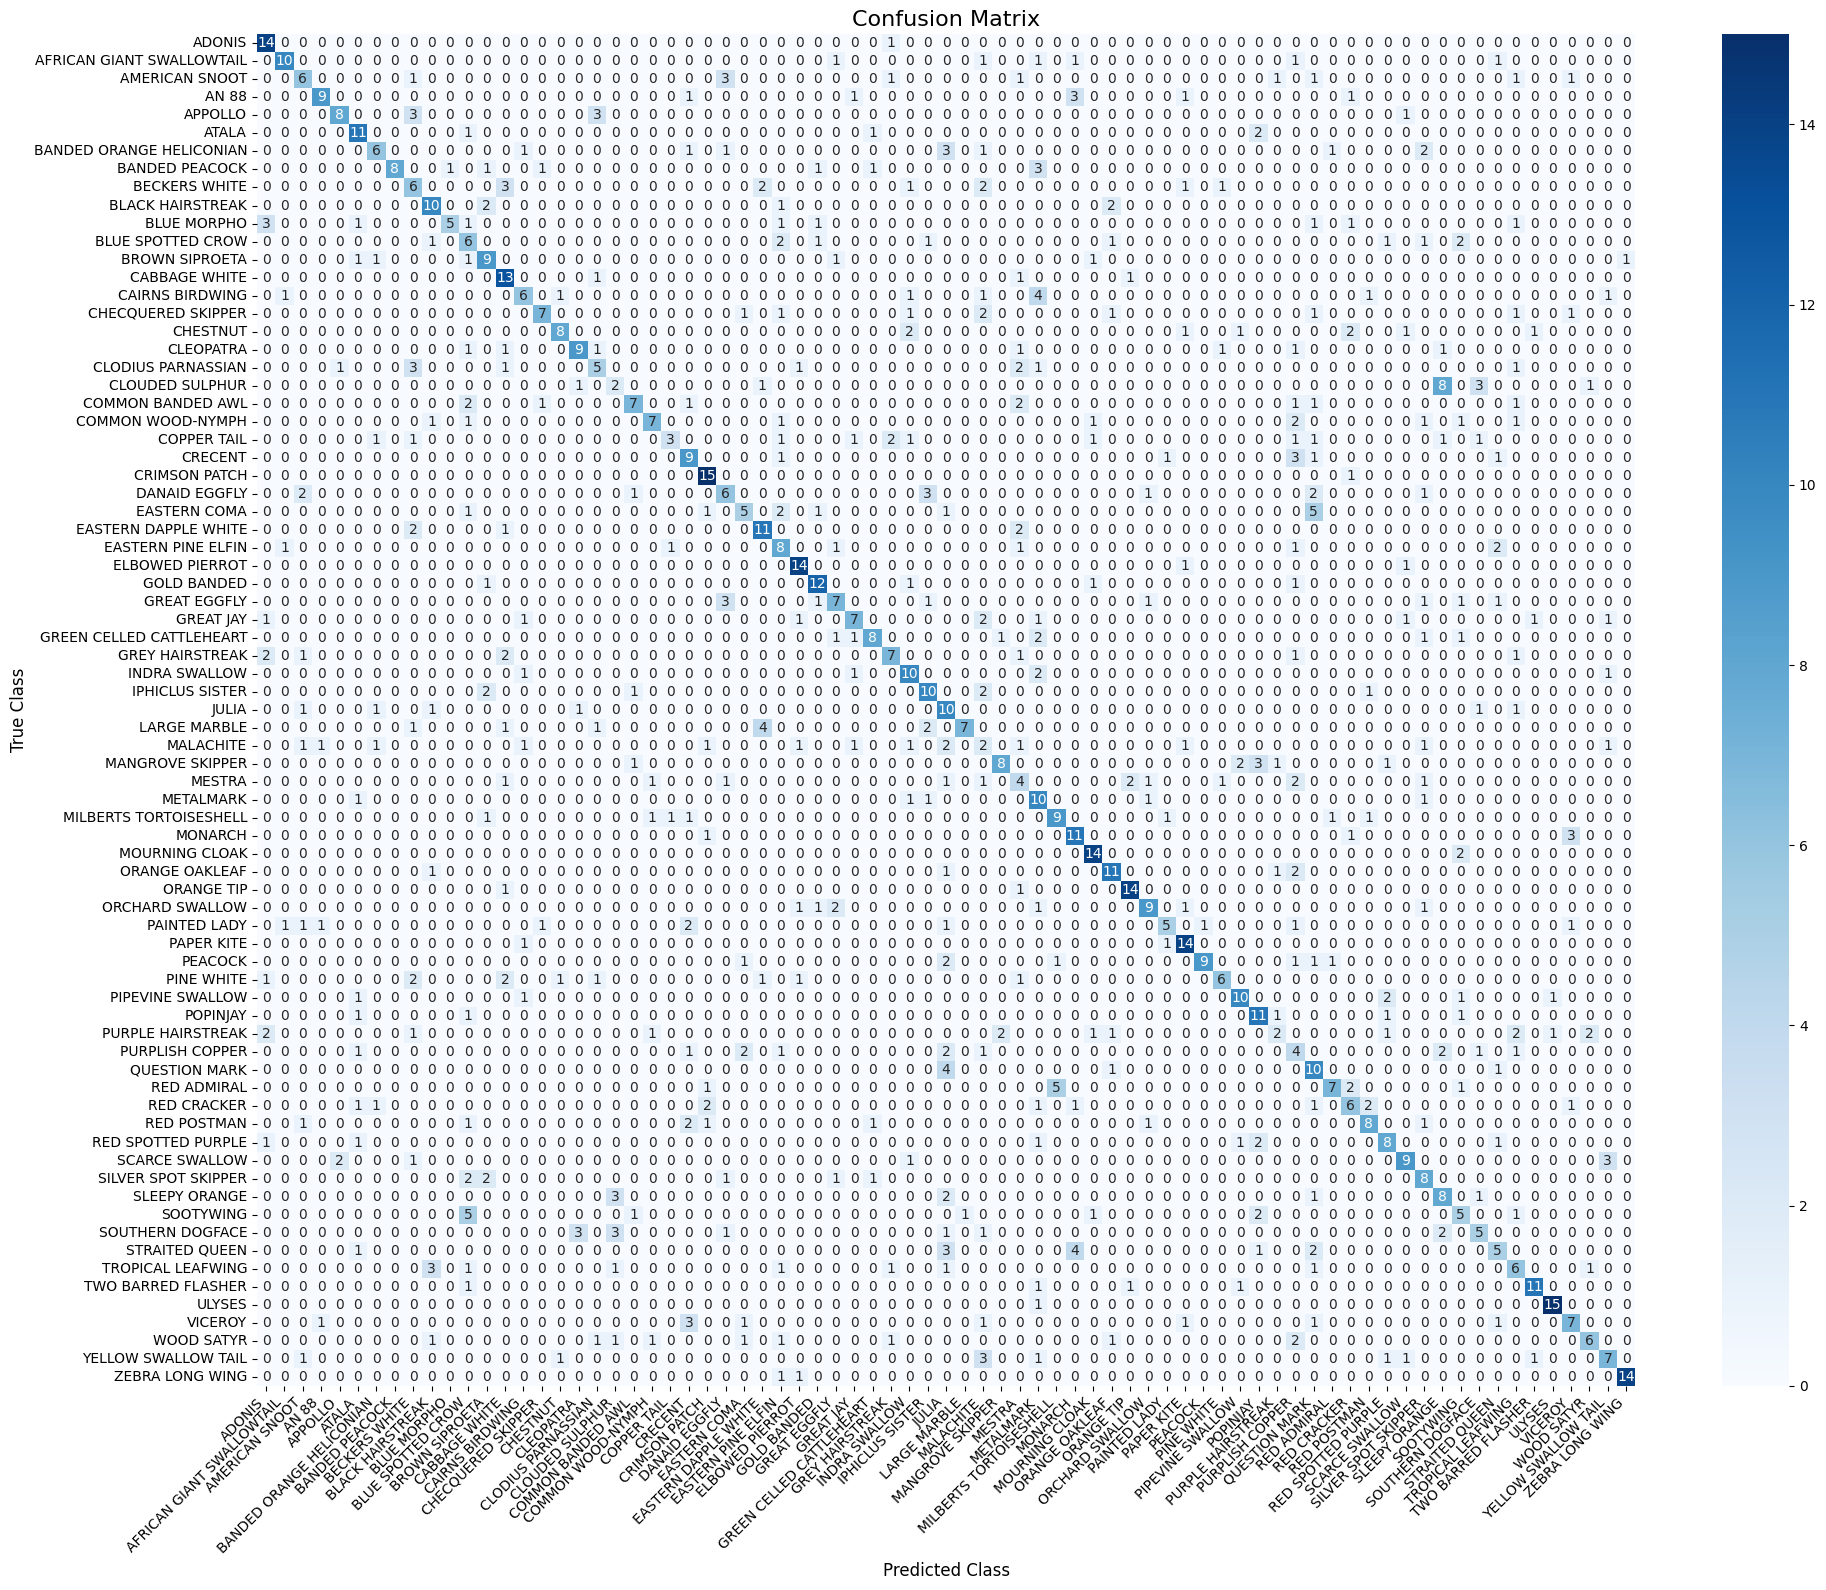

In [36]:
final_CNN_model = ButterflyCNN(**oversampled_cnn_best_config['architecture']).to(device)

if oversampled_cnn_best_config['loss'] == 'CrossEntropy':
    criterion_final = nn.CrossEntropyLoss()
else:
    criterion_final = nn.MultiMarginLoss()

if oversampled_cnn_best_config['optimizer'] == 'Adam':
    optimizer_final = optim.Adam(final_CNN_model.parameters(), lr=oversampled_cnn_best_config['learning_rate'])
else:
    optimizer_final = optim.RMSprop(final_CNN_model.parameters(), lr=oversampled_cnn_best_config['learning_rate'])

cnn_scheduler_final = optim.lr_scheduler.ReduceLROnPlateau(optimizer_final, mode='min', factor=0.5, patience=3)

print(f"Training the final CNN with the best configuration: {oversampled_cnn_best_config}")
cnn_over_history_final = train_model(model=final_CNN_model, 
                            train_loader=oversampled_train_loader, 
                            val_loader=oversampled_val_loader, 
                            criterion=criterion_final, 
                            optimizer=optimizer_final, 
                            device=device, 
                            num_epochs=45,
                            scheduler=cnn_scheduler_final)

# save the best model configuration for later use
checkpoint_cnn = {
    'model_name': 'ButterflyCNN',
    'best_config': oversampled_cnn_best_config,
    'model_weights': final_CNN_model.state_dict(),
    'class_names': test_dataset.classes
}

dir_save = os.path.dirname(path) # Main Project Directory
save_path = os.path.join(dir_save, 'models/best_over_cnn_model.pth')

torch.save(checkpoint_cnn, save_path)
print(f"Model saved successfully to: {save_path}")

# Evaluate the final model on the Test Set
labels_reais, labels_previstos = evaluate_on_test(
    final_CNN_model,
    oversampled_test_loader,
    device,
    class_names=test_dataset.classes
)

### Competition

In [42]:
models_dir = os.path.join(os.path.dirname(path), 'models')

loaded_cnn_checkpoint = torch.load(os.path.join(models_dir, 'best_over_cnn_model.pth'), map_location=device)
loaded_cnn_model = ButterflyCNN(**loaded_cnn_checkpoint['best_config']['architecture']).to(device)
loaded_cnn_model.load_state_dict(loaded_cnn_checkpoint['model_weights'])

generate_kaggle_submission(model=loaded_cnn_model, 
                           test_dir=test_img_dir, 
                           transform=data_transform,
                           class_names=test_dataset.classes,
                           device=device,
                           save_name='submission_oversampled_cnn.csv')

A processar 1300 imagens para a submissão...
Sucesso! Submissão guardada em: /content/drive/MyDrive/Universidade/Mestrado/2 Semestre/Aprendizagem Computacional Avançada/AML_Butterfly/submission_oversampled_cnn.csv


,filename,label
0,Image_0.jpg,MILBERTS TORTOISESHELL
1,Image_1.jpg,APPOLLO
2,Image_10.jpg,RED SPOTTED PURPLE
3,Image_100.jpg,POPINJAY
4,Image_1000.jpg,MALACHITE
...,...,...
1295,Image_995.jpg,INDRA SWALLOW
1296,Image_996.jpg,AMERICAN SNOOT
1297,Image_997.jpg,LARGE MARBLE
1298,Image_998.jpg,MONARCH
